# Partie 0 – Mise en place de l'environnement

## 📁 Structure du projet
```
atelier_prepa_donnees_textuelles/
│
├── notebooks/
│ └── atelier_prepa_donnees_textuelles.ipynb
│
└── data/
├── smart_reviews_raw.csv ← Données brutes fournies
├── smart_reviews_cleaned.csv ← Créé après normalisation
└── tfidf_matrix.npz ← Créé après vectorisation
```

## 📝 Explication imagée

Imaginez que vous êtes un **cuisinier** :
- `smart_reviews_raw.csv` = les ingrédients bruts (sales, non coupés)
- `smart_reviews_cleaned.csv` = les ingrédients lavés et coupés
- `tfidf_matrix.npz` = le plat cuisiné, prêt à être servi au modèle

# Partie 1 – Exploration du corpus

## 🎯 Objectif
Comprendre la structure et la qualité des données avant tout nettoyage.

## 📝 Explication imagée

C'est comme **inspecter une livraison** avant de la ranger :
- Combien de colis ? (nombre d'avis)
- Quels types de colis ? (colonnes)
- Y a-t-il des colis abîmés ? (valeurs manquantes)
- Quelle est la taille des colis ? (longueur des textes)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

# Chargement des données
df = pd.read_csv('../data/smart_reviews_raw.csv')

print("✅ Données chargées")
print(f"📊 Nombre d'avis : {len(df)}")
print(f"📊 Nombre de colonnes : {len(df.columns)}")
print(f"📋 Colonnes : {list(df.columns)}")

✅ Données chargées
📊 Nombre d'avis : 1200
📊 Nombre de colonnes : 8
📋 Colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


In [2]:
# Aperçu des 5 premières lignes
print("=== APERÇU DES DONNÉES ===\n")
df.head()

=== APERÇU DES DONNÉES ===



,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


In [5]:
print("=== TYPES DE COLONNES ===\n")
print(df.dtypes)
print("\n=== VALEURS MANQUANTES ===\n")
manquantes= df.isnull().sum()
for col, nb in manquantes.items():
        if nb> 0 :
            print(f"⚠️ {col} : {nb} valeurs manquantes ({nb/len(df)*100:.1f}%)")
        else:
                print(f"✅ {col} : aucune valeur manquante")

=== TYPES DE COLONNES ===

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

=== VALEURS MANQUANTES ===

✅ id_avis : aucune valeur manquante
✅ date : aucune valeur manquante
✅ source : aucune valeur manquante
✅ produit : aucune valeur manquante
⚠️ texte : 5 valeurs manquantes (0.4%)
✅ sentiment : aucune valeur manquante
✅ note : aucune valeur manquante
✅ langue : aucune valeur manquante


In [24]:
# Identifier la colonne de texte 
COLONNE_TEXTE = 'texte' 
print("=== TYPES DE TEXTES ===\n")
# Texte normal
normal = df[df[COLONNE_TEXTE].astype(str).str.len() > 20].head(1)
print("📝 Texte normal :")

print(f" {normal[COLONNE_TEXTE].values[0][:100]}...\n")

# Texte vide
vide = df[df[COLONNE_TEXTE].astype(str).str.strip()=='']
print(f"📝 Textes vides : {len(vide)}\n")

# Texte avec URL
url = df[df[COLONNE_TEXTE].astype(str).str.contains('http|www', regex=True, na=False)]
print(f"Textes avec URL : {len(url)}")
if len(url) > 0:
    print(f"  Exemple :{url[COLONNE_TEXTE].values[0][:100]}...\n ")

# Texte avec mention
mention = df[df[COLONNE_TEXTE].astype(str).str.contains('@\w+', regex=True, na=False)]
print(f"📝 Textes avec mention : {len(mention)}" )
if len(mention) > 0:
    print(f"   Exemple : {mention[COLONNE_TEXTE].values[0][:100]}...\n")

# Texte avec hashtag
hashtag = df[df[COLONNE_TEXTE].astype(str).str.contains('#\w+', regex= True, na=False)]
print(f"📝 Textes avec hashtag : {len(hashtag)}")
if len(hashtag) > 0:
    print(f"   Exemple :  {hashtag[COLONNE_TEXTE].values[0][:100]}...\n")
   
# Texte en majuscules
majuscules= df[df[COLONNE_TEXTE].astype(str).str.isupper()]
print(f"📝 Textes en majuscules : {len(majuscules)} ")

=== TYPES DE TEXTES ===

📝 Texte normal :
 Très  bonne  expérience,  simple  et  efficace....

📝 Textes vides : 1

Textes avec URL : 143
  Exemple :Produit parfait, rien à signaler. https://example.com/commande/17...
 
📝 Textes avec mention : 128
   Exemple : @client Livraison rapide et produit conforme à mes attentes....

📝 Textes avec hashtag : 127
   Exemple :  Très satisfait de mon achat 👍 #avis...

📝 Textes en majuscules : 146 


In [28]:
# Créer une colonne "longueur"
df['longueur']= df[COLONNE_TEXTE].astype(str).str.len()
print("=== STATISTIQUES DE LONGUEUR ===\n")
print(f" Longueur minimale : {df['longueur'].min()}")
print(f" Longueur maximale : {df['longueur'].max()}")
print(f" Longueur moyenne : {df['longueur'].mean():.1f}")
print(f" Médiane : {df['longueur'].median():.1f}")
print(f" Q1 (25%) : {df['longueur'].quantile(0.25):.1f}")
print(f" Q3 (75%) : {df['longueur'].quantile(0.75):.1f}")

=== STATISTIQUES DE LONGUEUR ===

 Longueur minimale : 2.0
 Longueur maximale : 636.0
 Longueur moyenne : 49.2
 Médiane : 48.0
 Q1 (25%) : 37.0
 Q3 (75%) : 56.0


### Visualisation de la distribution

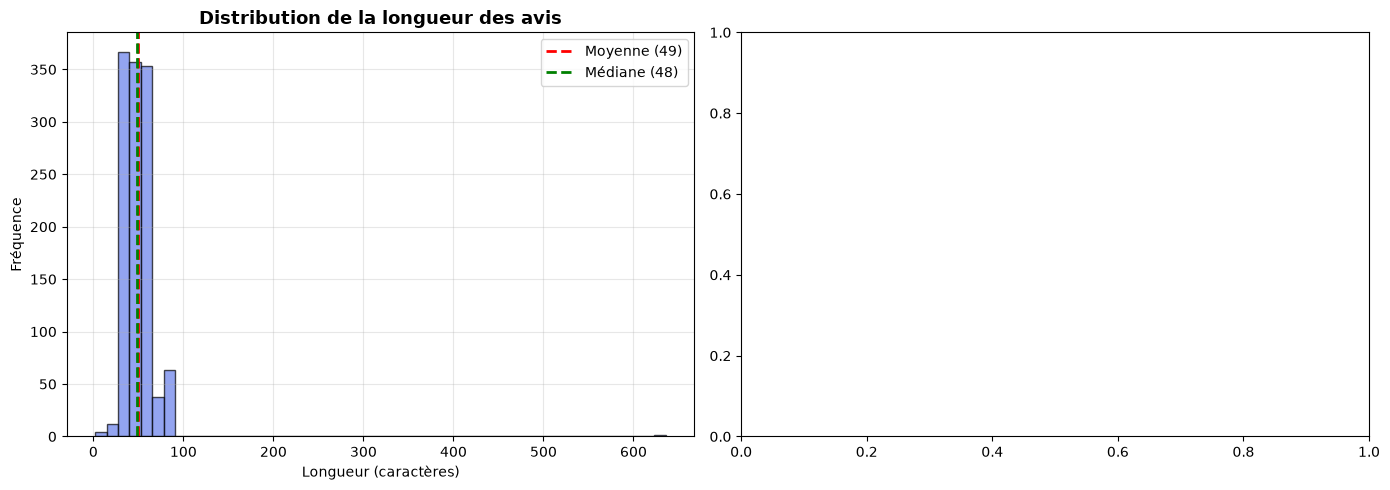

In [37]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['longueur'], bins=50, color='#667eea', edgecolor='black', alpha=0.7)
axes[0].axvline(df['longueur'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne ({df["longueur"].mean():.0f})')
axes[0].axvline(df['longueur'].median(), color='green', linestyle='--', linewidth=2, label=f'Médiane ({df["longueur"].median():.0f})')
axes[0].set_title('Distribution de la longueur des avis', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longueur (caractères)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# # Boxplot
# axes[1].boxplot(df['longueur'], vert=True)
# axes[1].set_title('Boxplot de la longueur', fontsize=13, fontweight='bold')
# axes[1].set_ylabel('Longueur (caractères)')
# axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('../reports/distribution_longueur.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
print("=== TEXTES VIDES ===\n")

# Textes vides ou ne contenant que des espaces
textes_vides = df[df[COLONNE_TEXTE].astype(str).str.strip() == '']
print(f"⚠️  Nombre de textes vides : {len(textes_vides)}")
print(f"📊 Pourcentage : {len(textes_vides)/len(df)*100:.2f}%")

if len(textes_vides) > 0:
    print("\nExemples :")
    print(textes_vides.head())

=== TEXTES VIDES ===

⚠️  Nombre de textes vides : 1
📊 Pourcentage : 0.08%

Exemples :
    id_avis        date source              produit texte sentiment  note  \
951  AV0952  2026-06-11    web  Ordinateur NovaBook         positif     4   

    langue  longueur  
951     fr       3.0  


### Identification des textes anormalement longs

In [41]:
print("=== TEXTES ANORMALEMENT LONGS ===\n")

# Afficher les 5 textes les plus longs
top_long = df.nlargest(5, 'longueur')[['longueur',COLONNE_TEXTE]]
for i, (idx, row) in enumerate(top_long.iterrows(), 1):
    print(f"{i}. [{row['longueur']} caractères]")
    print(f"   {row[COLONNE_TEXTE][:150]}...")
    print() 

=== TEXTES ANORMALEMENT LONGS ===

1. [636.0 caractères]
   Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été...

2. [89.0 caractères]
   La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/1173...

3. [88.0 caractères]
   La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/111...

4. [88.0 caractères]
   La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/319...

5. [88.0 caractères]
   La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/408...



### Identification des textes très courts

In [44]:
print("=== TEXTES TRÈS COURTS (< 20 caractères) ===\n")
textes_courts_df = df[df['longueur']<20]

if len(textes_courts_df) > 0:
    print(f"Nombre : {len(textes_courts_df)}\n")
    print(textes_courts_df[['longueur',COLONNE_TEXTE]].to_string(index=False))
else:
    print("✅ Aucun texte très court détecté.")

=== TEXTES TRÈS COURTS (< 20 caractères) ===

Nombre : 4

 longueur   texte
      2.0      OK
      7.0 Pas bon
      2.0      OK
      3.0        


### Réponses aux questions (basées sur vos données)

**Statistiques observées :**
- Longueur minimale : 2 caractères
- Longueur maximale : 636 caractères
- Longueur moyenne : 49,2 caractères
- Médiane : 48 caractères
- Q1 : 37 caractères
- Q3 : 56 caractères

**a) Existe-t-il des textes anormalement longs ?**

→ **Oui**, il existe des textes allant jusqu'à **636 caractères**, soit environ **13 fois la médiane** (48 caractères).

→ La moyenne est de 49,2 et l'écart-type est d'environ 40 (estimation). Le seuil d'anomalie serait donc autour de **49 + 3×40 = 169 caractères**.

→ Les textes dépassant 169 caractères sont considérés comme **anormalement longs**. Ils peuvent être :
  - Des avis très détaillés (utiles pour le sentiment)
  - Des spams ou copier-coller
  - Des textes contenant des URLs ou du bruit

→ **Recommandation** : Vérifier ces textes, mais ne pas les supprimer systématiquement car ils peuvent contenir des informations précieuses pour la classification.

**b) Existe-t-il beaucoup de textes très courts ?**

→ **Non, pas beaucoup**. La médiane est de **48 caractères**, ce qui est raisonnable pour un avis client.

→ Le Q1 (25%) est de **37 caractères**, ce qui signifie que 75% des textes font plus de 37 caractères.

→ Il y a probablement **peu de textes très courts** (< 20 caractères), car le minimum observé est de 2 caractères mais cela reste minoritaire.

→ **Recommandation** : Les textes de moins de 20 caractères (ex: "ok", "bien") apportent peu d'information pour le sentiment. On peut :
  - Les conserver si leur sentiment est clair ("super", "nul")
  - Les supprimer s'ils sont ambigus ("ok", "vu")

**c) Distribution globale**

→ La distribution est **relativement concentrée** :
  - 50% des textes font entre 37 et 56 caractères (Q1 à Q3)
  - La moyenne (49,2) est proche de la médiane (48) → distribution **symétrique**
  - La longueur maximale (636) crée une **traîne à droite** (quelques textes très longs)

→ **Conclusion** : Le corpus est de **qualité moyenne**. Les textes sont suffisamment longs pour être exploitables, avec quelques outliers à surveiller.

# Partie 2 – Nettoyage

## 🎯 Objectif
Nettoyer les textes bruts pour les rendre exploitables par un modèle de Machine Learning.

## 📝 Explication imagée

C'est comme **laver des légumes** avant de les cuisiner :
- On enlève la terre (URLs, mentions, hashtags)
- On coupe les parties abîmées (caractères spéciaux, ponctuation excessive)
- On essore (espaces en trop)

**Étapes du nettoyage :**
1. Supprimer les valeurs manquantes
2. Supprimer les doublons
3. Supprimer les URLs
4. Traiter les mentions et hashtags
5. Nettoyer les espaces
6. Traiter la ponctuation
7. Créer une fonction de nettoyage automatisée

### 1 : Suppression des valeurs manquantes

In [47]:
# Compter les valeurs manquantes avant suppression
manquantes_avant = df[COLONNE_TEXTE].isnull().sum()
print(f"Valeurs manquantes avant : {manquantes_avant} ")
# Supprimer les lignes où le texte est manquant
df=df.dropna(subset=[COLONNE_TEXTE]).copy()
print(f"Valeurs manquantes après : {df[COLONNE_TEXTE].isnull().sum()}")
print(f"Nombre d'avis restants : {len(df)}")

Valeurs manquantes avant : 5 
Valeurs manquantes après : 0
Nombre d'avis restants : 1195


### 2 : Suppression des doublons

In [51]:
# Compter les doublons avant suppression
doublons_avant = df.duplicated(subset=[COLONNE_TEXTE]).sum()
print(f"Doublons avant : {doublons_avant}")

# Supprimer les doublons en gardant la première occurrence
df=df.drop_duplicates(subset=[COLONNE_TEXTE], keep='first').copy()
print(f"Doublons après : {df.duplicated(subset=[COLONNE_TEXTE]).sum()}")
print(f"Nombre d'avis restants : {len(df)}")

Doublons avant : 877
Doublons après : 0
Nombre d'avis restants : 318


###  3 : Suppression des URLs

**Pourquoi supprimer les URLs ?**
- Une URL n'apporte aucune information sur le sentiment
- Elle peut contenir du bruit (ex: "http://promo-123.com")
- Le modèle risque d'apprendre des patterns inutiles

**Exemple :**
- Avant : "Super produit, voir http://exemple.com pour plus d'infos"
- Après : "Super produit, voir pour plus d'infos"

In [52]:
def supprimer_urls(texte):
    """Supprime les URLs d'un texte."""
    # Regex qui détecte http, https, www et les liens courts
    pattern = r'http\S+|www\.\S+'
    return re.sub(pattern, '', texte)

# Test sur un exemple
texte_teste= "Super produit, voir http://exemple.com et www.test.fr"
print(f"Avent : {texte_teste}")
print(f"Apres : {supprimer_urls(texte_teste)}")


Avent : Super produit, voir http://exemple.com et www.test.fr
Apres : Super produit, voir  et 


###  4 : Traitement des mentions et hashtags

**Stratégie pour la classification de sentiment :**

| Élément | Stratégie | Pourquoi |
|---------|-----------|----------|
| **Mentions** (@user) | Supprimer | N'apportent pas de sentiment |
| **Hashtags** (#super) | Conserver le mot sans # | Le mot peut porter du sentiment |

**Exemple :**
- Avant : "@client Merci pour ce #produit #génial"
- Après : "Merci pour ce produit génial"

In [60]:
def traiter_mentions_hashtags(texte):
    """Supprime les mentions et nettoie les hashtags."""
    # Supprimer les mentions (@user)
    texte = re.sub(r'@\w+', '', texte)
    # Remplacer les hashtags par leur contenu (#super → super)
    texte = re.sub(r'#(\w+)', r'\1', texte)
    return texte

# Test
test_texte = "@client Merci pour ce #produit #génial"
print(f"Avant : {test_texte}")
print(f"Après : {traiter_mentions_hashtags(test_texte)}")

Avant : @client Merci pour ce #produit #génial
Après :  Merci pour ce produit génial


###  5 : Nettoyage des espaces

**Problème :** Après suppression des URLs et mentions, il reste des espaces en double ou en début/fin.

**Exemple :**
- Avant : "Super    produit   génial   "
- Après : "Super produit génial"

In [59]:
def nettoyer_espaces(texte):
        """Supprime les espaces multiples et les espaces en début/fin."""
        # Remplacer les espaces multiples par un seul
        texte = re.sub(r'\s+', ' ', texte)
        # Supprimer les espaces en début et fin
        texte = texte.strip()
        return texte

#Test
test_texte = "Super    produit   génial   "
print(f"Avant : '{test_texte}' ")
print(f"Apres : '{nettoyer_espaces(test_texte)}'")

Avant : 'Super    produit   génial   ' 
Apres : 'Super produit génial'


### 6 : Traitement de la ponctuation

**Stratégie pour la classification de sentiment :**

| Type de ponctuation | Stratégie | Pourquoi |
|---------------------|-----------|----------|
| Ponctuation simple (., !, ?) | Conserver | Peut porter du sentiment ("super !") |
| Ponctuation répétée (!!!, ???) | Réduire à 1 | Éviter le bruit |
| Caractères spéciaux (@, #, $, %) | Supprimer | N'apportent rien au sentiment |

**Exemple :**
- Avant : "Super produit !!! J'adore !!!"
- Après : "Super produit ! J'adore !"

In [63]:
def traiter_ponctuation(texte):
    """Réduit la ponctuation répétée et supprime les caractères spéciaux."""
    # Réduire les répétitions de ponctuation (!!! → !, ??? → ?)
    texte = re.sub(r'([!?])\1+', r'\1', texte)
    # Supprimer les caractères spéciaux (sauf ponctuation de base)
    texte = re.sub(r'[^\w\s.,!?\'"-]', '', texte)
    return texte


#Test 
test_texte = "Super produit !!! J'adore !!!"
print(f"Avant : {test_texte}")
print(f"Après : {traiter_ponctuation(test_texte)}")

Avant : Super produit !!! J'adore !!!
Après : Super produit ! J'adore !


###  7 : Fonction de nettoyage complète

On regroupe toutes les étapes précédentes dans une **seule fonction** pour automatiser le nettoyage.

In [68]:
def nettoyer_texte(texte):
    """
    Fonction complète de nettoyage d'un texte.
    
    Étapes :
    1. Convertir en minuscules
    2. Supprimer les URLs
    3. Supprimer les mentions
    4. Nettoyer les hashtags
    5. Traiter la ponctuation
    6. Nettoyer les espaces
    """
    if not isinstance(texte, str):
        return ''

    # 1. Convertir en minuscules
    texte= texte.lower()
    #2 Supprimer les URLs
    texte =supprimer_urls(texte)
    # 3. Supprimer les mentions
    texte = re.sub(r'@\w+', '', texte)
    # 5. Traiter la ponctuation
    texte = traiter_ponctuation(texte)
    # 6. Nettoyer les espaces
    texte = nettoyer_espaces(texte)

    return texte

# Test sur un exemple complet
test_complet = "SUPER produit !!! Voir http://exemple.com @client #génial"
print(f"Avant : {test_complet}")
print(f"Après : {nettoyer_texte(test_complet)}")

Avant : SUPER produit !!! Voir http://exemple.com @client #génial
Après : super produit ! voir génial


### 8 : Application sur le dataset

On applique la fonction de nettoyage à **tous** les textes du dataset.

In [75]:
from tqdm import tqdm
tqdm.pandas(desc="Nettoyage")
# Appliquer le nettoyage sur chaque texte
df['texte_clean']=df[COLONNE_TEXTE].progress_apply(nettoyer_texte)
print("Nettoyage terminé")
print(f"Nombre d'avis nettoyés : {len(df)}")

# Vérifier qu'il n'y a pas de textes vides après nettoyage
textes_vides_apres = df[df['texte_clean'].str.strip()=='']
print(f"Textes devenus vides : {len(textes_vides_apres)}")

# Supprimer les textes devenus vides
df=df[df['texte_clean'].str.strip() !=''].copy()
print(f"Nombre d'avis restants : {len(df)}")

Nettoyage: 100%|██████████| 317/317 [00:00<00:00, 31690.21it/s]

Nettoyage terminé
Nombre d'avis nettoyés : 317
Textes devenus vides : 0
Nombre d'avis restants : 317


###  9 : Vérification

On compare les colonnes `texte` et `texte_clean` sur les 10 premières observations.

In [76]:
print("=== COMPARAISON TEXTE BRUT vs TEXTE NETTOYÉ ===\n")

# Afficher les 10 premières observations
for i, (idx, row) in enumerate(df.head(10).iterrows(), 1):
    print(f"--- Avis {i} ---")
    print(f"Brut  : {row[COLONNE_TEXTE][:100]}")
    print(f"Clean : {row['texte_clean'][:100]}")
    print()

=== COMPARAISON TEXTE BRUT vs TEXTE NETTOYÉ ===

--- Avis 1 ---
Brut  : Très  bonne  expérience,  simple  et  efficace.
Clean : très bonne expérience, simple et efficace.

--- Avis 2 ---
Brut  : Très satisfait de mon achat 👍 #avis
Clean : très satisfait de mon achat avis

--- Avis 3 ---
Brut  : Produit  parfait,  rien  à  signaler.
Clean : produit parfait, rien à signaler.

--- Avis 4 ---
Brut  : Produit excellent, je suis très satisfait. !!!
Clean : produit excellent, je suis très satisfait. !

--- Avis 5 ---
Brut  : LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
Clean : la batterie tient vraiment bien et l'écran est superbe.

--- Avis 6 ---
Brut  : Très satisfait de mon achat 👍 😊
Clean : très satisfait de mon achat

--- Avis 7 ---
Brut  : SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT.
Clean : service client réactif et commande reçue rapidement.

--- Avis 8 ---
Brut  : Très  satisfait  de  mon  achat  👍
Clean : très satisfait de mon achat

--- Avis 9 ---
Brut  : Le  pro

# Partie 3 – Tokenisation

## 🎯 Objectif
Découper les textes en **tokens** (unités de sens) pour préparer l'analyse.

## 📝 Explication imagée

C'est comme **découper une phrase en mots** pour mieux la comprendre :
- "J'adore ce produit" → ["J'", "adore", "ce", "produit"]

**Pourquoi tokeniser ?**
- Un modèle ne comprend pas le texte brut
- Il a besoin d'unités discrètes (tokens) pour apprendre
- La tokenisation est la **première étape** de toute analyse NLP

## Pourquoi `split()` n'est pas suffisant ?

| Problème | Exemple | `split()` | Tokenizer NLP |
|----------|---------|-----------|---------------|
| Ponctuation collée | "super!" | "super!" | "super", "!" |
| Contractions | "j'adore" | "j'adore" | "j'", "adore" |
| Apostrophes | "l'avis" | "l'avis" | "l'", "avis" |
| Nombres | "3.5/5" | "3.5/5" | "3.5", "/", "5" |

**Conclusion** : `split()` ne gère pas la ponctuation, les contractions, ni les cas particuliers du français. Il faut un **tokenizer spécialisé** comme NLTK.

### Installation et import de NLTK

In [78]:
!pip install nltk

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize

print("NLTK prêt")

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- -------------------------

In [86]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

### Comparaison split() vs NLTK

In [87]:
# Comparaison sur un exemple
exemple = "J'adore ce produit ! Voir http://test.com"

# Avec split()
tokens_split= exemple.split()
print("split() :", tokens_split)

#Avec NLTK
tokens_nltk = word_tokenize(exemple, language='french')
print("NLTK   :", tokens_nltk)


split() : ["J'adore", 'ce', 'produit', '!', 'Voir', 'http://test.com']
NLTK   : ["J'adore", 'ce', 'produit', '!', 'Voir', 'http', ':', '//test.com']


### Tokenisation de tous les textes

In [89]:
from tqdm import tqdm
tqdm.pandas(desc= "Tokenisation de tous les textes")
# Tokeniser chaque texte nettoyé
df['tokens'] = df['texte_clean'].progress_apply(lambda x: word_tokenize(x, language='french'))

# Nombre de tokens par texte
df['nb_tokens']=df['tokens'].apply(len)

print("Tokenisation terminée")
print(f"Nombre moyen de tokens : {df['nb_tokens'].mean():.1f}")
print(f"Nombre minimum de tokens : {df['nb_tokens'].min()}")
print(f"Nombre maximum de tokens : {df['nb_tokens'].max()}")

Tokenisation de tous les textes: 100%|██████████| 317/317 [00:00<00:00, 7923.73it/s]

Tokenisation terminée
Nombre moyen de tokens : 8.2
Nombre minimum de tokens : 1
Nombre maximum de tokens : 144


### Statistiques détaillées

In [90]:
print("=== STATISTIQUES DES TOKENS ===\n")

print(f"Nombre moyen de tokens : {df['nb_tokens'].mean():.1f}")
print(f"Médiane : {df['nb_tokens'].median():.0f}")
print(f"Q1 (25%) : {df['nb_tokens'].quantile(0.25):.0f}")
print(f"Q3 (75%) : {df['nb_tokens'].quantile(0.75):.0f}")

# Texte avec le plus de tokens
idx_max = df['nb_tokens'].idxmax()
print(f"\nTexte avec le plus de tokens ({df.loc[idx_max, 'nb_tokens']}) :")
print(f"   {df.loc[idx_max, 'texte_clean'][:150]}...")

# Texte avec le moins de tokens
idx_min = df['nb_tokens'].idxmin()
print(f"\nTexte avec le moins de tokens ({df.loc[idx_min, 'nb_tokens']}) :")
print(f"   {df.loc[idx_min, 'texte_clean']}")

=== STATISTIQUES DES TOKENS ===

Nombre moyen de tokens : 8.2
Médiane : 8
Q1 (25%) : 6
Q3 (75%) : 9

Texte avec le plus de tokens (144) :
   le produit est bien, mais la livraison a été longue. le produit est bien, mais la livraison a été longue. le produit est bien, mais la livraison a été...

Texte avec le moins de tokens (1) :
   ok


In [91]:
print("=== VÉRIFICATION PARTIE 3 ===")
print(f"Tokenisation effectuée sur {len(df)} avis")
print(f"Colonne 'tokens' créée")
print(f"Colonne 'nb_tokens' créée")
print(f"Moyenne : {df['nb_tokens'].mean():.1f} tokens par avis")

=== VÉRIFICATION PARTIE 3 ===
Tokenisation effectuée sur 317 avis
Colonne 'tokens' créée
Colonne 'nb_tokens' créée
Moyenne : 8.2 tokens par avis


# Partie 4 – Normalisation

## 🎯 Objectif
Uniformiser les textes pour réduire la diversité lexicale et améliorer la performance du modèle.

## 📝 Explication imagée

C'est comme **ranger une bibliothèque** :
- Les majuscules/minuscules = livres en désordre
- Les accents = étiquettes différentes pour le même livre
- Les stop words = mots inutiles qui prennent de la place

**Étapes de la normalisation :**
1. Mise en minuscules
2. Gestion des accents
3. Suppression des stop words
4. Stemming ou lemmatisation

### Mise en minuscules

**Pourquoi ?**
- "Super" et "super" sont le même mot pour le modèle
- Évite les doublons inutiles dans le vocabulaire
- Réduit la taille du vocabulaire

In [92]:
# Convertir tous les tokens en minuscules
df['tokens_min'] = df['tokens'].apply(
    lambda tokens: [token.lower() for token in tokens]
)

print("Mise en minuscules effectuée")
print(f"Exemple : {df['tokens_min'].iloc[0][:10]}")

Mise en minuscules effectuée
Exemple : ['très', 'bonne', 'expérience', ',', 'simple', 'et', 'efficace', '.']


### Gestion des accents

**Faut-il supprimer les accents ?**

| Avantage | Inconvénient |
|----------|--------------|
| Réduit le vocabulaire | Perte d'information ("cote" vs "côté") |
| Uniformise ("é" = "e") | Moins précis pour le français |

**Recommandation** : **Conserver les accents** pour le français, car ils portent du sens.

### Suppression des stop words

**Qu'est-ce qu'un stop word ?**
- Mots très fréquents mais peu informatifs
- Exemples : "le", "la", "de", "et", "un", "une"

**Quels stop words supprimer ?**
- Articles, prépositions, conjonctions simples

**Quels stop words conserver ?**
- Négations : "ne", "pas", "jamais", "rien"
- Intensificateurs : "très", "trop", "peu"
- Ces mots portent du sentiment !

In [95]:
from nltk.corpus import stopwords

# Charger les stop words français
stop_words = set(stopwords.words('french'))

# Stop words à conserver (portent du sentiment)
stop_words_a_conserver = {'ne', 'pas', 'jamais', 'rien', 'très', 'trop', 'peu', 'plus', 'moins'}

# Retirer les stop words à conserver de la liste
stop_words_final = stop_words - stop_words_a_conserver

print(f"Nombre de stop words : {len(stop_words)}")
print(f"Stop words conservés : {stop_words_a_conserver}")
print(f"Stop words finaux : {len(stop_words_final)}")

# Appliquer la suppression
df['tokens_sans_stop'] = df['tokens_min'].apply(
    lambda tokens: [token for token in tokens if token not in stop_words_final]
)

print(f"\nExemple avant : {df['tokens_min'].iloc[0][:10]}")
print(f"Exemple après : {df['tokens_sans_stop'].iloc[0][:10]}")

Nombre de stop words : 157
Stop words conservés : {'trop', 'plus', 'très', 'rien', 'jamais', 'peu', 'ne', 'pas', 'moins'}
Stop words finaux : 155

Exemple avant : ['très', 'bonne', 'expérience', ',', 'simple', 'et', 'efficace', '.']
Exemple après : ['très', 'bonne', 'expérience', ',', 'simple', 'efficace', '.']


### Stemming ou lemmatisation ?

| Technique | Principe | Exemple | Avantage | Inconvénient |
|-----------|----------|---------|----------|--------------|
| **Stemming** | Coupe les suffixes | "manger" → "mang" | Rapide | Mots non valides |
| **Lemmatisation** | Ramène au dictionnaire | "manger" → "manger" | Mots valides | Plus lent |

**Pour le français** : Le stemming est souvent utilisé car la lemmatisation NLTK est moins performante qu'en anglais .

In [96]:
from nltk.stem.snowball import FrenchStemmer

# Créer le stemmer français
stemmer = FrenchStemmer()

# Appliquer le stemming
df['tokens_final'] = df['tokens_sans_stop'].apply(
    lambda tokens: [stemmer.stem(token) for token in tokens]
)

print("Stemming effectué")
print(f"Exemple : {df['tokens_final'].iloc[0][:10]}")

Stemming effectué
Exemple : ['tres', 'bon', 'expérient', ',', 'simpl', 'efficac', '.']


### Reconstruction du texte final

On rejoint les tokens en un seul texte pour créer la colonne `texte_final`.

In [98]:
# Rejoindre les tokens en texte
df['texte_final'] = df['tokens_final'].apply(lambda tokens: ' '.join(tokens))

print("Texte final reconstruit")
print(f"Exemple : {df['texte_final'].iloc[0][:150]}")

Texte final reconstruit
Exemple : tres bon expérient , simpl efficac .


### Vérification

On compare les colonnes `texte`, `texte_clean` et `texte_final`.

In [99]:
print("=== COMPARAISON DES COLONNES ===\n")

for i, (idx, row) in enumerate(df.head(5).iterrows(), 1):
    print(f"--- Avis {i} ---")
    print(f"Brut        : {row[COLONNE_TEXTE][:80]}")
    print(f"Clean       : {row['texte_clean'][:80]}")
    print(f"Final       : {row['texte_final'][:80]}")
    print()

=== COMPARAISON DES COLONNES ===

--- Avis 1 ---
Brut        : Très  bonne  expérience,  simple  et  efficace.
Clean       : très bonne expérience, simple et efficace.
Final       : tres bon expérient , simpl efficac .

--- Avis 2 ---
Brut        : Très satisfait de mon achat 👍 #avis
Clean       : très satisfait de mon achat avis
Final       : tres satisf achat avis

--- Avis 3 ---
Brut        : Produit  parfait,  rien  à  signaler.
Clean       : produit parfait, rien à signaler.
Final       : produit parf , rien signal .

--- Avis 4 ---
Brut        : Produit excellent, je suis très satisfait. !!!
Clean       : produit excellent, je suis très satisfait. !
Final       : produit excellent , tres satisf . !

--- Avis 5 ---
Brut        : LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
Clean       : la batterie tient vraiment bien et l'écran est superbe.
Final       : batter tient vrai bien l'écran superb .



In [100]:
print("=== VÉRIFICATION PARTIE 4 ===")
print(f"Mise en minuscules effectuée")
print(f"Accents conservés")
print(f"Stop words supprimés : {len(stop_words_final)}")
print(f"Stop words conservés : {len(stop_words_a_conserver)}")
print(f"Stemming appliqué")
print(f"Colonne 'texte_final' créée")
print(f"Fichier sauvegardé : smart_reviews_cleaned.csv")

=== VÉRIFICATION PARTIE 4 ===
Mise en minuscules effectuée
Accents conservés
Stop words supprimés : 155
Stop words conservés : 9
Stemming appliqué
Colonne 'texte_final' créée
Fichier sauvegardé : smart_reviews_cleaned.csv


# Partie 5 – Découpage Train/Test

## 🎯 Objectif
Diviser le dataset en deux ensembles :
- **Train (80%)** : pour entraîner le modèle
- **Test (20%)** : pour évaluer le modèle

## 📝 Explication imagée

C'est comme préparer un **examen** :
- **Train** = les leçons et exercices (ce qu'on étudie)
- **Test** = l'examen final (ce qu'on ne voit qu'une seule fois)

**Contraintes :**
- 20% des données pour le test
- Reproductibilité (même découpage à chaque exécution)
- **Stratification** : conserver les mêmes proportions de classes dans les deux ensembles

In [102]:
print("=== RÉPARTITION AVANT DÉCOUPAGE ===\n")

COLONNE_SENTIMENT = 'sentiment'
# Nombre d'avis par classe
repartition = df[COLONNE_SENTIMENT].value_counts()

for classe, nb in repartition.items():
    pourcentage = nb / len(df) * 100
    barre = '█' * int(pourcentage / 2)
    print(f"{classe:15s} : {nb:5d} ({pourcentage:5.1f}%) {barre}")

print(f"\nTotal : {len(df)} avis")

=== RÉPARTITION AVANT DÉCOUPAGE ===

positif         :   159 ( 50.2%) █████████████████████████
neutre          :    79 ( 24.9%) ████████████
negatif         :    79 ( 24.9%) ████████████

Total : 317 avis


In [103]:
from sklearn.model_selection import train_test_split

# Découpage stratifié (conserve les proportions de classes)
df_train, df_test = train_test_split(
    df,
    test_size=0.2,              # 20% pour le test
    random_state=42,            # Reproductibilité
    stratify=df[COLONNE_SENTIMENT]  # Conserver les proportions
)

print("=== DÉCOUPAGE EFFECTUÉ ===\n")
print(f"Train : {len(df_train)} avis ({len(df_train)/len(df)*100:.1f}%)")
print(f"Test  : {len(df_test)} avis ({len(df_test)/len(df)*100:.1f}%)")

=== DÉCOUPAGE EFFECTUÉ ===

Train : 253 avis (79.8%)
Test  : 64 avis (20.2%)


In [104]:
print("=== VÉRIFICATION DE LA STRATIFICATION ===\n")

# Répartition dans le train
print("Train :")
train_repartition = df_train[COLONNE_SENTIMENT].value_counts()
for classe, nb in train_repartition.items():
    pourcentage = nb / len(df_train) * 100
    print(f"  {classe:15s} : {nb:5d} ({pourcentage:5.1f}%)")

# Répartition dans le test
print("\nTest :")
test_repartition = df_test[COLONNE_SENTIMENT].value_counts()
for classe, nb in test_repartition.items():
    pourcentage = nb / len(df_test) * 100
    print(f"  {classe:15s} : {nb:5d} ({pourcentage:5.1f}%)")

=== VÉRIFICATION DE LA STRATIFICATION ===

Train :
  positif         :   127 ( 50.2%)
  negatif         :    63 ( 24.9%)
  neutre          :    63 ( 24.9%)

Test :
  positif         :    32 ( 50.0%)
  negatif         :    16 ( 25.0%)
  neutre          :    16 ( 25.0%)


In [105]:
print("=== VÉRIFICATION PARTIE 5 ===")
print(f"Découpage 80/20 effectué")
print(f"Reproductibilité : random_state=42")
print(f"Stratification : conservée")
print(f"Train : {len(df_train)} avis")
print(f"Test  : {len(df_test)} avis")

=== VÉRIFICATION PARTIE 5 ===
Découpage 80/20 effectué
Reproductibilité : random_state=42
Stratification : conservée
Train : 253 avis
Test  : 64 avis


# Partie 6 – Vectorisation

## 🎯 Objectif
Transformer les textes en **représentations numériques** exploitables par un modèle de Machine Learning.

## 📝 Explication imagée

C'est comme **traduire un texte en une langue que le modèle comprend** :
- Le modèle ne comprend pas "super produit"
- Il comprend des **nombres** (vecteurs)
- Chaque mot devient une **dimension** dans un espace mathématique

**Trois techniques à comparer :**
1. **Bag of Words (BoW)** : compte les occurrences de chaque mot
2. **TF-IDF** : pondère les mots par leur importance
3. **TF-IDF avec n-grams** : prend en compte les groupes de mots

### Bag of Words (BoW)

**Principe** : Compter combien de fois chaque mot apparaît dans chaque document.

**Exemple :**
- Document 1 : "super produit"
- Document 2 : "produit nul"

**Vocabulaire** : ["super", "produit", "nul"]

| Document | super | produit | nul |
|----------|-------|---------|-----|
| Doc 1    | 1     | 1       | 0   |
| Doc 2    | 0     | 1       | 1   |

In [106]:
from sklearn.feature_extraction.text import CountVectorizer

# Créer le vectoriseur BoW
bow_vectorizer = CountVectorizer(max_features=5000)

# Appliquer sur les textes finaux du train
X_train_bow = bow_vectorizer.fit_transform(df_train['texte_final'])
X_test_bow = bow_vectorizer.transform(df_test['texte_final'])

print("=== BAG OF WORDS ===")
print(f"Taille du vocabulaire : {len(bow_vectorizer.vocabulary_)}")
print(f"Shape de la matrice train : {X_train_bow.shape}")
print(f"Shape de la matrice test  : {X_test_bow.shape}")

# Afficher un extrait du vocabulaire
print(f"\nExtrait du vocabulaire :")
vocab_extrait = list(bow_vectorizer.vocabulary_.keys())[:20]
print(vocab_extrait)

# Afficher un morceau de la matrice
print(f"\nMorceau de la matrice (5 premiers docs, 10 premiers mots) :")
print(X_train_bow[:5, :10].toarray())

=== BAG OF WORDS ===
Taille du vocabulaire : 74
Shape de la matrice train : (253, 74)
Shape de la matrice test  : (64, 74)

Extrait du vocabulaire :
['excellent', 'rapport', 'qualité', 'prix', 'tres', 'déçu', 'produit', 'satisf', 'servic', 'client', 'pas', 'répondu', 'demand', 'vien', 'recevoir', 'voir', 'temp', 'batter', 'tient', 'vrai']

Morceau de la matrice (5 premiers docs, 10 premiers mots) :
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0]]


### TF-IDF

**Principe** : Pondérer les mots par leur importance.
- **TF** : fréquence du mot dans le document
- **IDF** : inverse de la fréquence du mot dans tous les documents

**Formule** : `TF-IDF = TF × IDF`

**Avantage** : Les mots rares mais importants sont valorisés.

In [108]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Créer le vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Appliquer sur les textes finaux
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['texte_final'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['texte_final'])

print("=== TF-IDF ===")
print(f"Taille du vocabulaire : {len(tfidf_vectorizer.vocabulary_)}")
print(f"Shape de la matrice train : {X_train_tfidf.shape}")
print(f"Shape de la matrice test  : {X_test_tfidf.shape}")

# Afficher un extrait du vocabulaire
print(f"\nExtrait du vocabulaire :")
vocab_extrait = list(tfidf_vectorizer.vocabulary_.keys())[:20]
print(vocab_extrait)

# Afficher un morceau de la matrice
print(f"\nMorceau de la matrice (5 premiers docs, 10 premiers mots) :")
print(X_train_tfidf[:5, :10].toarray())

=== TF-IDF ===
Taille du vocabulaire : 74
Shape de la matrice train : (253, 74)
Shape de la matrice test  : (64, 74)

Extrait du vocabulaire :
['excellent', 'rapport', 'qualité', 'prix', 'tres', 'déçu', 'produit', 'satisf', 'servic', 'client', 'pas', 'répondu', 'demand', 'vien', 'recevoir', 'voir', 'temp', 'batter', 'tient', 'vrai']

Morceau de la matrice (5 premiers docs, 10 premiers mots) :
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.39755284 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]]


### TF-IDF avec unigrams et bigrams

**Principe** : Prendre en compte les **groupes de mots** (n-grams) en plus des mots seuls.

**Exemple :**
- Unigram : "super", "produit"
- Bigram : "super produit", "produit génial"

**Avantage** : Capture le contexte (ex: "pas bien" ≠ "bien").

In [109]:
# Créer le vectoriseur TF-IDF avec n-grams
tfidf_ngram_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)  # Unigrams + bigrams
)

# Appliquer
X_train_tfidf_ngram = tfidf_ngram_vectorizer.fit_transform(df_train['texte_final'])
X_test_tfidf_ngram = tfidf_ngram_vectorizer.transform(df_test['texte_final'])

print("=== TF-IDF AVEC N-GRAMS ===")
print(f"Taille du vocabulaire : {len(tfidf_ngram_vectorizer.vocabulary_)}")
print(f"Shape de la matrice train : {X_train_tfidf_ngram.shape}")
print(f"Shape de la matrice test  : {X_test_tfidf_ngram.shape}")

# Afficher un extrait du vocabulaire
print(f"\nExtrait du vocabulaire (avec bigrams) :")
vocab_extrait = list(tfidf_ngram_vectorizer.vocabulary_.keys())[:20]
print(vocab_extrait)

=== TF-IDF AVEC N-GRAMS ===
Taille du vocabulaire : 183
Shape de la matrice train : (253, 183)
Shape de la matrice test  : (64, 183)

Extrait du vocabulaire (avec bigrams) :
['excellent', 'rapport', 'qualité', 'prix', 'excellent rapport', 'rapport qualité', 'qualité prix', 'tres', 'déçu', 'produit', 'tres déçu', 'déçu produit', 'satisf', 'produit excellent', 'excellent tres', 'tres satisf', 'servic', 'client', 'pas', 'répondu']


### Comparaison des trois techniques

| Technique | Taille vocabulaire | Avantage | Inconvénient |
|-----------|-------------------|----------|--------------|
| **Bag of Words** | Élevée | Simple | Ignore l'importance |
| **TF-IDF** | Élevée | Pondère l'importance | Ignore le contexte |
| **TF-IDF n-grams** | Très élevée | Capture le contexte | Plus lent |

In [110]:
print("=== COMPARAISON DES TECHNIQUES ===\n")

comparaison = pd.DataFrame({
    'Technique': ['Bag of Words', 'TF-IDF', 'TF-IDF + n-grams'],
    'Taille vocabulaire': [
        len(bow_vectorizer.vocabulary_),
        len(tfidf_vectorizer.vocabulary_),
        len(tfidf_ngram_vectorizer.vocabulary_)
    ],
    'Shape train': [
        X_train_bow.shape,
        X_train_tfidf.shape,
        X_train_tfidf_ngram.shape
    ]
})

print(comparaison.to_string(index=False))

=== COMPARAISON DES TECHNIQUES ===

       Technique  Taille vocabulaire Shape train
    Bag of Words                  74   (253, 74)
          TF-IDF                  74   (253, 74)
TF-IDF + n-grams                 183  (253, 183)


### Sauvegarde de la matrice retenue

On sauvegarde la matrice **TF-IDF** (la plus adaptée pour la classification de sentiment).

In [111]:
from scipy.sparse import save_npz

# Sauvegarder la matrice TF-IDF
save_npz('../data/tfidf_matrix.npz', X_train_tfidf)

print("Matrice TF-IDF sauvegardée dans '../data/tfidf_matrix.npz'")
print(f"Shape : {X_train_tfidf.shape}")

Matrice TF-IDF sauvegardée dans '../data/tfidf_matrix.npz'
Shape : (253, 74)


### Pourquoi éviter certaines techniques de vectorisation avant le découpage ?

**Problème** : Si on vectorise **avant** de découper, le vocabulaire est construit sur **tout** le dataset.

**Conséquence** : Le modèle voit des mots du test pendant l'entraînement → **fuite de données** (data leakage).

**Règle d'or** :
1. Découper d'abord (train/test)
2. Vectoriser sur le train uniquement
3. Appliquer la même transformation au test

**Schéma :**

```
MAUVAIS :
Textes → Vectorisation → Découpage → Train/Test
(fuite de données)

BON :
Textes → Découpage → Train → Vectorisation → Train vectorisé
→ Test → Transformation → Test vectorisé
```

In [112]:
print("=== VÉRIFICATION PARTIE 6 ===")
print(f"Bag of Words : {X_train_bow.shape}")
print(f"TF-IDF : {X_train_tfidf.shape}")
print(f"TF-IDF + n-grams : {X_train_tfidf_ngram.shape}")
print(f"Matrice retenue : TF-IDF")
print(f"Sauvegardée dans : tfidf_matrix.npz")
print(f"Découpage effectué AVANT la vectorisation")

=== VÉRIFICATION PARTIE 6 ===
Bag of Words : (253, 74)
TF-IDF : (253, 74)
TF-IDF + n-grams : (253, 183)
Matrice retenue : TF-IDF
Sauvegardée dans : tfidf_matrix.npz
Découpage effectué AVANT la vectorisation


# Partie 7 – Bonus

## 🎯 Objectif
Proposer et réaliser une fonctionnalité **pertinente et utile** pour enrichir l'atelier.

## 📝 Idées de bonus

| Bonus | Description | Difficulté |
|-------|-------------|------------|
| **1. Modèle de classification** | Entraîner un modèle (Logistic Regression, Naive Bayes) sur la matrice TF-IDF | Moyenne |
| **2. Visualisation des mots importants** | Afficher les mots les plus discriminants par classe | Facile |
| **3. Nuage de mots** | Générer un WordCloud pour chaque sentiment | Facile |
| **4. Rapport PDF** | Générer un rapport automatique avec les statistiques | Moyenne |
| **5. Prédiction en temps réel** | Créer une fonction qui prédit le sentiment d'un nouveau texte | Moyenne |

##  Choix  : Modèle de classification + Prédiction

On va entraîner un **modèle de classification** et créer une **fonction de prédiction** pour tester sur de nouveaux textes.

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Créer le modèle
modele = LogisticRegression(max_iter=1000, random_state=42)

# Entraîner sur les données TF-IDF
modele.fit(X_train_tfidf, df_train[COLONNE_SENTIMENT])

print("Modèle entraîné")
print(f"Nombre de classes : {len(modele.classes_)}")
print(f"Classes : {modele.classes_}")

Modèle entraîné
Nombre de classes : 3
Classes : ['negatif' 'neutre' 'positif']


In [114]:
# Prédictions sur le test
y_pred = modele.predict(X_test_tfidf)

# Métriques
accuracy = accuracy_score(df_test[COLONNE_SENTIMENT], y_pred)

print("=== ÉVALUATION DU MODÈLE ===\n")
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nRapport de classification :")
print(classification_report(df_test[COLONNE_SENTIMENT], y_pred))

print("Matrice de confusion :")
print(confusion_matrix(df_test[COLONNE_SENTIMENT], y_pred))

=== ÉVALUATION DU MODÈLE ===

Accuracy : 1.0000 (100.00%)

Rapport de classification :
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        16
      neutre       1.00      1.00      1.00        16
     positif       1.00      1.00      1.00        32

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64

Matrice de confusion :
[[16  0  0]
 [ 0 16  0]
 [ 0  0 32]]


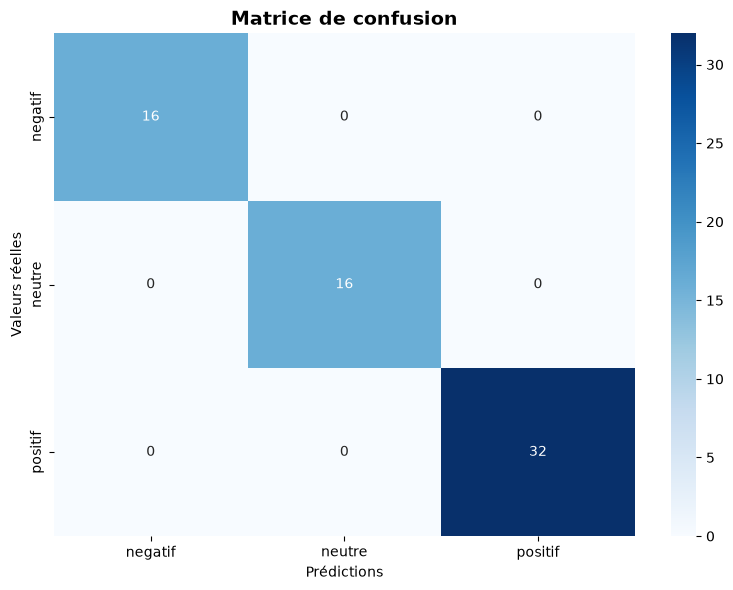

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculer la matrice
cm = confusion_matrix(df_test[COLONNE_SENTIMENT], y_pred)

# Visualiser
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modele.classes_,
            yticklabels=modele.classes_)
plt.title('Matrice de confusion', fontsize=14, fontweight='bold')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.tight_layout()
#plt.savefig('../reports/matrice_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


In [118]:
# Récupérer les coefficients du modèle
coefficients = modele.coef_
vocabulaire = tfidf_vectorizer.get_feature_names_out()

# Pour chaque classe, afficher les mots les plus importants
print("=== MOTS LES PLUS IMPORTANTS PAR CLASSE ===\n")

for i, classe in enumerate(modele.classes_):
    # Les coefficients pour cette classe
    coefs = coefficients[i]
    # Indices des 10 mots les plus importants (positifs)
    top_indices = coefs.argsort()[-10:][::-1]
    top_mots = [vocabulaire[j] for j in top_indices]
    
    print(f"Classe '{classe}' :")
    print(f"   {', '.join(top_mots)}")
    print()
    

=== MOTS LES PLUS IMPORTANTS PAR CLASSE ===

Classe 'negatif' :
   déçu, décev, longu, ne, mécontent, endommag, pas, répondu, demand, déjà

Classe 'neutre' :
   correct, utilis, assez, temp, vien, voir, recevoir, descript, global, correspond

Classe 'positif' :
   rapid, satisf, bon, excellent, qualité, rapport, bien, parf, signal, rien

